# 09 - Final Report Figures And Tables

Goal: package the project into portfolio-ready artifacts.

The previous notebooks developed the analysis step by step. This final notebook does not introduce new methodology. Instead, it curates the final story:

- What is the product question?
- What is the causal setup?
- What are the headline descriptive and adjusted estimates?
- Where does the effect appear strongest?
- What policy direction does the analysis suggest?
- What limitations should be stated clearly?

The notebook saves polished figures and tables into `notebooks/projects/project_1_ranking/writeup/figures/` and `notebooks/projects/project_1_ranking/writeup/tables/`.

## Executive Summary

This project studies a core recommendation-system question:

> Does placing an item higher in the ranking cause more engagement, or are high-ranked items simply more relevant and therefore more likely to be clicked anyway?

Using MIND impression logs, we define:

- **Treatment**: an item appears in the top 3 positions.
- **Control**: an item appears below position 3.
- **Outcome**: the displayed item is clicked.
- **Covariates**: user-history, item metadata, slate-size, time, and item-exposure features.

The final report should make a careful claim: top-ranked exposure is associated with higher click probability after causal adjustment, but the estimate depends on observational assumptions and should be validated with online experimentation.

### Notebook Setup

This cell imports the libraries needed to regenerate final figures and tables. It also sets a consistent plotting style and suppresses a harmless LightGBM/sklearn feature-name warning that can appear after preprocessing.

In [1]:
from pathlib import Path
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning,
)

This cell prepares the notebook environment for final report tables, figures, and portfolio artifacts. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


### Create Report Output Folders

This cell finds the project root and creates output directories for final artifacts. Figures are saved as PNG files and tables are saved as CSV files. The written files can be referenced from the README, final memo, or portfolio page.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
REPORT_DIR = PROJECT_ROOT / "notebooks/projects/project_1_ranking/writeup"
FIGURE_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


def save_table(table, name):
    path = TABLE_DIR / f"{name}.csv"
    table.to_csv(path, index=False)
    return path


FIGURE_DIR, TABLE_DIR

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/figures'),
 PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables'))

The printed paths are a reproducibility checkpoint. Once the notebook can find the input data and output folders, the analysis can run from a clean checkout without manual path edits.


### Load The Analysis Table

This cell loads the processed impression-level table. Each row represents one displayed item inside an impression. This table is the source for the report's descriptive figures and compact causal-estimation rerun.

In [3]:
df = pd.read_parquet(DATA_PATH)

pd.Series(
    {
        "displayed_item_rows": len(df),
        "impressions": df["impression_id"].nunique(),
        "users": df["user_id"].nunique(),
        "news_items": df["news_id"].nunique(),
        "overall_ctr": df["clicked"].mean(),
        "max_rank_position": df["rank_position"].max(),
    }
)

displayed_item_rows   737762.0000
impressions            20000.0000
users                  15427.0000
news_items             12349.0000
overall_ctr                0.0405
max_rank_position        294.0000
dtype: float64

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


## Figure 1: Naive CTR By Rank

This figure establishes the descriptive fact that motivates the causal analysis. Items displayed at higher positions receive more clicks. The figure is intentionally labeled **naive** because it does not adjust for relevance, popularity, or ranking-policy selection.

### Create And Save Naive CTR Figures

This cell computes click-through rate by exact rank and by rank bucket. It saves a polished line chart for exact ranks 1 through 50 and a table of bucket-level CTR values.

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/figures/01_naive_ctr_by_rank.png'),
 PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/rank_bucket_ctr.csv'),
   rank_bucket  clicks  impressions    ctr
 0           1    2229        20000 0.1114
 1         2-3    3729        38646 0.0965
 2        4-10    6828       114987 0.0594
 3       11-25    7455       181168 0.0411
 4       26-50    5340       177476 0.0301
 5         51+    4313       205485 0.0210)

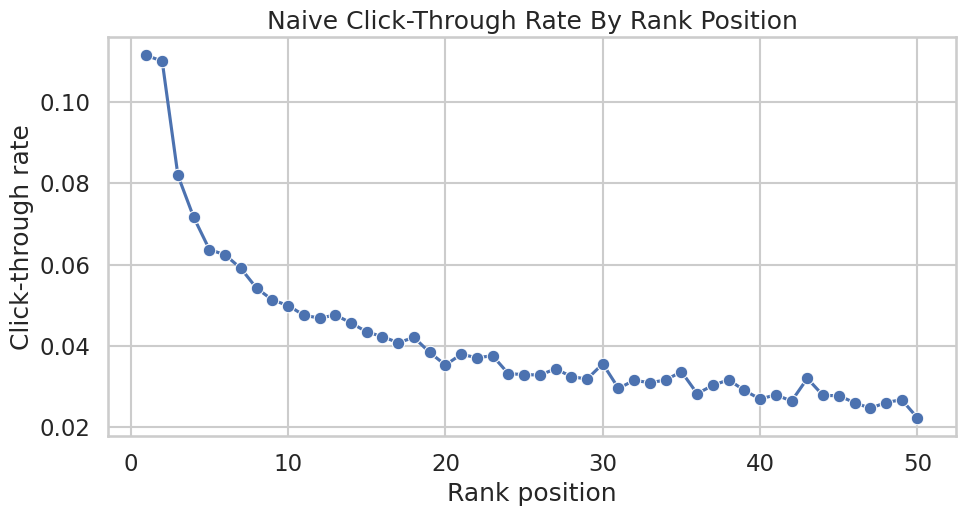

In [4]:
ctr_by_rank = (
    df.groupby("rank_position")
    .agg(clicks=("clicked", "sum"), impressions=("clicked", "size"), ctr=("clicked", "mean"))
    .reset_index()
)

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=ctr_by_rank.query("rank_position <= 50"), x="rank_position", y="ctr", marker="o")
plt.title("Naive Click-Through Rate By Rank Position")
plt.xlabel("Rank position")
plt.ylabel("Click-through rate")
plt.tight_layout()
ctr_figure_path = save_figure("01_naive_ctr_by_rank")

rank_bins = [0, 1, 3, 10, 25, 50, df["rank_position"].max()]
rank_labels = ["1", "2-3", "4-10", "11-25", "26-50", "51+"]
rank_bucket_table = (
    df.assign(
        rank_bucket=pd.cut(
            df["rank_position"],
            bins=rank_bins,
            labels=rank_labels,
            include_lowest=True,
            duplicates="drop",
        )
    )
    .groupby("rank_bucket", observed=True)
    .agg(clicks=("clicked", "sum"), impressions=("clicked", "size"), ctr=("clicked", "mean"))
    .reset_index()
)
rank_bucket_table_path = save_table(rank_bucket_table, "rank_bucket_ctr")

ctr_figure_path, rank_bucket_table_path, rank_bucket_table

This cell creates reusable project artifacts for the writeup. Saving figures, tables, limitations, and resume bullets makes the analysis easier to present outside the notebook itself.


## Final Causal Estimate Rerun

The earlier notebooks contain the detailed methodology. For the final report, we rerun a compact version of the primary adjusted estimate using LightGBM nuisance models and cross-fitted AIPW.

This produces report-ready numbers for:

- Naive lift.
- IPW-adjusted lift.
- Outcome-regression lift.
- Doubly robust AIPW lift.

The rerun uses a deterministic sample so the notebook stays fast and reproducible.

### Create The Final Modeling Sample

This cell creates the modeling sample and explicit treatment/outcome columns. `treatment` is top-3 exposure and `outcome` is click. `log_item_exposures` is included as a non-click item exposure proxy.

In [5]:
MODEL_SAMPLE_SIZE = 60_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

pd.Series(
    {
        "rows": len(model_df),
        "treatment_rate_top_3": model_df["treatment"].mean(),
        "click_rate": model_df["outcome"].mean(),
    }
)

rows                   60000.0000
treatment_rate_top_3       0.0800
click_rate                 0.0393
dtype: float64

This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


### Define Final Model Features

This cell defines the adjustment features used for the final compact AIPW rerun. They mirror the main analysis: user history, slate size, simple text features, time context, exposure, category, and subcategory.

In [6]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]
propensity_features = numeric_features + categorical_features
outcome_numeric_features = numeric_features + ["treatment"]
outcome_features = outcome_numeric_features + categorical_features

propensity_features, outcome_features

(['history_len',
  'candidate_set_size',
  'title_length',
  'abstract_length',
  'hour',
  'day_of_week',
  'log_item_exposures',
  'category',
  'subcategory'],
 ['history_len',
  'candidate_set_size',
  'title_length',
  'abstract_length',
  'hour',
  'day_of_week',
  'log_item_exposures',
  'treatment',
  'category',
  'subcategory'])

The feature lists define what information is allowed into the adjustment models. These are pre-treatment or contextual variables intended to reduce confounding without using the outcome itself as an input.


### Define LightGBM AIPW Helpers

This cell defines reusable helpers for preprocessing, LightGBM models, weighted means, and cross-fitted AIPW estimation. The code is compact because this notebook focuses on final outputs rather than teaching every estimator detail again.

In [7]:
def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="infrequent_if_exist",
                                min_frequency=50,
                                sparse_output=True,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ]
    )


def make_lgbm_classifier():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=160,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def make_lgbm_regressor():
    return lgb.LGBMRegressor(
        objective="regression",
        n_estimators=160,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def make_pipeline(task, numeric_cols, categorical_cols):
    model = make_lgbm_classifier() if task == "classification" else make_lgbm_regressor()
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
            ("model", model),
        ]
    )


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)

This cell creates reusable modeling machinery rather than a final result. The value is consistency: the same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


### Run Cross-Fitted AIPW For The Final Estimate Table

This cell fits cross-fitted propensity and outcome models, computes AIPW scores, and produces the final estimator comparison table. The table is saved for the report.

In [8]:
N_FOLDS = 2
EPS = 0.01

e_hat = np.zeros(len(model_df))
mu1_hat = np.zeros(len(model_df))
mu0_hat = np.zeros(len(model_df))
propensity_metrics = []
outcome_metrics = []

splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for fold, (train_idx, valid_idx) in enumerate(splitter.split(model_df[propensity_features], model_df["treatment"]), start=1):
    train_df = model_df.iloc[train_idx]
    valid_df = model_df.iloc[valid_idx]

    propensity_model = make_pipeline("classification", numeric_features, categorical_features)
    propensity_model.fit(train_df[propensity_features], train_df["treatment"])
    e_valid = propensity_model.predict_proba(valid_df[propensity_features])[:, 1]
    e_hat[valid_idx] = e_valid

    outcome_model = make_pipeline("regression", outcome_numeric_features, categorical_features)
    outcome_model.fit(train_df[outcome_features], train_df["outcome"])
    y_valid_hat = outcome_model.predict(valid_df[outcome_features])

    valid_treated = valid_df[propensity_features].copy()
    valid_treated["treatment"] = 1
    valid_treated = valid_treated[outcome_features]

    valid_control = valid_df[propensity_features].copy()
    valid_control["treatment"] = 0
    valid_control = valid_control[outcome_features]

    mu1_hat[valid_idx] = outcome_model.predict(valid_treated)
    mu0_hat[valid_idx] = outcome_model.predict(valid_control)

    propensity_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["treatment"], e_valid),
            "average_precision": average_precision_score(valid_df["treatment"], e_valid),
            "brier_score": brier_score_loss(valid_df["treatment"], e_valid),
        }
    )
    outcome_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["outcome"], y_valid_hat),
            "average_precision": average_precision_score(valid_df["outcome"], y_valid_hat),
            "brier_score": brier_score_loss(valid_df["outcome"], np.clip(y_valid_hat, 0, 1)),
        }
    )

model_df["e_hat"] = e_hat
model_df["mu1_hat"] = mu1_hat
model_df["mu0_hat"] = mu0_hat
model_df["mu_diff_hat"] = model_df["mu1_hat"] - model_df["mu0_hat"]

e = model_df["e_hat"].clip(EPS, 1 - EPS).to_numpy()
t_np = model_df["treatment"].to_numpy()
y_np = model_df["outcome"].to_numpy()
mu1 = model_df["mu1_hat"].to_numpy()
mu0 = model_df["mu0_hat"].to_numpy()

model_df["aipw_score"] = (mu1 - mu0) + t_np * (y_np - mu1) / e - (1 - t_np) * (y_np - mu0) / (1 - e)

ipw_weights = np.where(t_np == 1, 1 / e, 1 / (1 - e))
ipw_weights = np.clip(ipw_weights, None, np.quantile(ipw_weights, 0.99))
treated = t_np == 1
control = ~treated

naive_top3_ctr = model_df.loc[model_df["treatment"] == 1, "outcome"].mean()
naive_lower_ctr = model_df.loc[model_df["treatment"] == 0, "outcome"].mean()
ipw_top3_ctr = weighted_mean(y_np[treated], ipw_weights[treated])
ipw_lower_ctr = weighted_mean(y_np[control], ipw_weights[control])
dr_lift = model_df["aipw_score"].mean()
dr_se = model_df["aipw_score"].std(ddof=1) / np.sqrt(len(model_df))

estimator_comparison = pd.DataFrame(
    [
        {"estimator": "naive", "lift": naive_top3_ctr - naive_lower_ctr, "ci_95_lower": np.nan, "ci_95_upper": np.nan},
        {"estimator": "ipw_99cap", "lift": ipw_top3_ctr - ipw_lower_ctr, "ci_95_lower": np.nan, "ci_95_upper": np.nan},
        {"estimator": "outcome_regression", "lift": model_df["mu_diff_hat"].mean(), "ci_95_lower": np.nan, "ci_95_upper": np.nan},
        {"estimator": "aipw_lgbm", "lift": dr_lift, "ci_95_lower": dr_lift - 1.96 * dr_se, "ci_95_upper": dr_lift + 1.96 * dr_se},
    ]
)

estimator_table_path = save_table(estimator_comparison, "estimator_comparison")
nuisance_metrics = pd.concat(
    [
        pd.DataFrame(propensity_metrics).assign(model="propensity"),
        pd.DataFrame(outcome_metrics).assign(model="outcome"),
    ],
    ignore_index=True,
)
nuisance_metrics_path = save_table(nuisance_metrics, "nuisance_model_metrics")

estimator_table_path, nuisance_metrics_path, estimator_comparison

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/estimator_comparison.csv'),
 PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/nuisance_model_metrics.csv'),
             estimator    lift  ci_95_lower  ci_95_upper
 0               naive  0.0630          NaN          NaN
 1           ipw_99cap  0.0024          NaN          NaN
 2  outcome_regression  0.0016          NaN          NaN
 3           aipw_lgbm -0.0049      -0.0113       0.0014)

Cross-fitting creates out-of-sample nuisance predictions for treatment and outcome models. This reduces overfitting bias and makes the later doubly robust scores more credible.


### Save The Estimator Comparison Figure

This cell creates a polished estimator comparison plot for the final report. It contrasts the raw descriptive lift with adjusted estimates.

PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/figures/02_estimator_comparison.png')

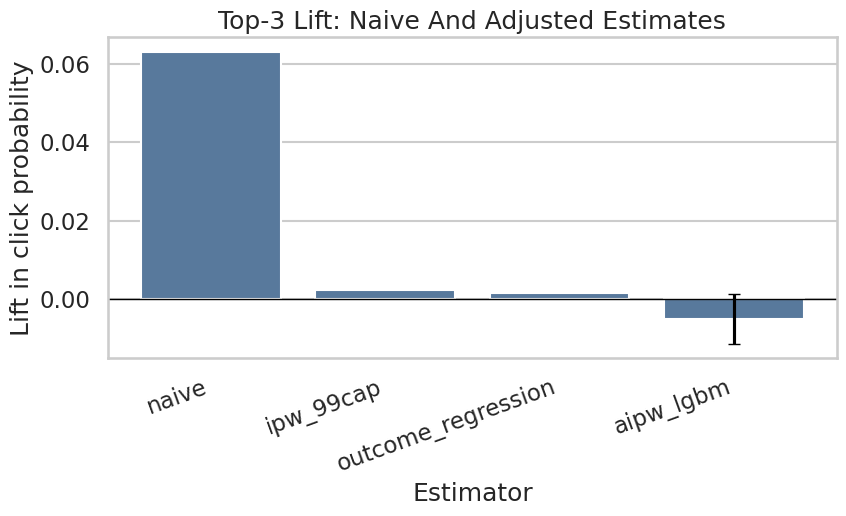

In [9]:
plt.figure(figsize=(9, 5.5))
sns.barplot(data=estimator_comparison, x="estimator", y="lift", color="#4C78A8")
for i, row in estimator_comparison.dropna(subset=["ci_95_lower", "ci_95_upper"]).iterrows():
    plt.errorbar(
        x=i,
        y=row["lift"],
        yerr=[[row["lift"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["lift"]]],
        fmt="none",
        color="black",
        capsize=4,
    )
plt.axhline(0, color="black", linewidth=1)
plt.title("Top-3 Lift: Naive And Adjusted Estimates")
plt.xlabel("Estimator")
plt.ylabel("Lift in click probability")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
estimator_figure_path = save_figure("02_estimator_comparison")

estimator_figure_path

This cell creates reusable project artifacts for the writeup. Saving figures, tables, limitations, and resume bullets makes the analysis easier to present outside the notebook itself.


## Final Heterogeneous Effect Summary

A global average effect is useful, but product teams need to know where an intervention is most valuable. This section summarizes AIPW scores by interpretable segments and saves the strongest segment table and a category-level figure.

### Create Segment Columns

This cell creates the segment columns used for final heterogeneity summaries: category, subcategory, history bucket, candidate-set bucket, item-exposure quartile, and time of day.

In [10]:
model_df["history_bucket"] = pd.cut(
    model_df["history_len"],
    bins=[-1, 0, 10, 30, 100, np.inf],
    labels=["0", "1-10", "11-30", "31-100", "101+"],
)
model_df["candidate_set_bucket"] = pd.cut(
    model_df["candidate_set_size"],
    bins=[0, 10, 25, 50, 100, np.inf],
    labels=["1-10", "11-25", "26-50", "51-100", "101+"],
    include_lowest=True,
)
model_df["item_exposure_quartile"] = pd.qcut(
    model_df["item_exposures"].rank(method="first"),
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)
model_df["time_of_day"] = pd.cut(
    model_df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["overnight", "morning", "afternoon", "evening", "late_evening"],
)

segment_columns = ["category", "subcategory", "history_bucket", "candidate_set_bucket", "item_exposure_quartile", "time_of_day"]
model_df[segment_columns].head()

,category,subcategory,history_bucket,candidate_set_bucket,item_exposure_quartile,time_of_day
0,news,newsworld,31-100,26-50,Q2,afternoon
1,sports,football_ncaa,31-100,51-100,Q2,overnight
2,news,elections-2020-us,31-100,51-100,Q2,afternoon
3,travel,traveltripideas,31-100,51-100,Q3,morning
4,news,newsworld,31-100,51-100,Q2,morning


The segment columns translate raw covariates into product-readable groups. This prepares the analysis for heterogeneity and policy simulation, where segment-level effects are easier to act on than row-level scores.


### Estimate Segment-Level AIPW Lift

This cell computes segment-level AIPW lift and confidence intervals. The segment table is used both for the heterogeneity figure and for the policy simulation.

In [11]:
def segment_effects(data, segment_col, min_rows=500, min_treated=30, min_control=250):
    rows = []
    for segment_value, group in data.groupby(segment_col, observed=True, dropna=False):
        n_rows = len(group)
        treated_rows = int(group["treatment"].sum())
        control_rows = n_rows - treated_rows
        if n_rows < min_rows or treated_rows < min_treated or control_rows < min_control:
            continue
        scores = group["aipw_score"].to_numpy()
        lift = scores.mean()
        se = scores.std(ddof=1) / np.sqrt(n_rows)
        naive_lift = group.loc[group["treatment"] == 1, "outcome"].mean() - group.loc[group["treatment"] == 0, "outcome"].mean()
        rows.append(
            {
                "segment_col": segment_col,
                "segment": str(segment_value),
                "rows": n_rows,
                "treated_rows": treated_rows,
                "control_rows": control_rows,
                "naive_lift": naive_lift,
                "aipw_lift": lift,
                "standard_error": se,
                "ci_95_lower": lift - 1.96 * se,
                "ci_95_upper": lift + 1.96 * se,
                "promotion_opportunities": control_rows,
            }
        )
    return pd.DataFrame(rows).sort_values("aipw_lift", ascending=False).reset_index(drop=True)


effect_tables = {
    segment_col: segment_effects(model_df, segment_col)
    for segment_col in segment_columns
}
all_segment_effects = pd.concat(effect_tables.values(), ignore_index=True)
top_segment_effects = all_segment_effects.sort_values("aipw_lift", ascending=False).head(25)
top_segment_table_path = save_table(top_segment_effects, "top_segment_effects")

top_segment_table_path, top_segment_effects.head(10)

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/top_segment_effects.csv'),
              segment_col            segment  rows  treated_rows  control_rows  \
 14           subcategory       baseball_mlb   607            38           569   
 54  candidate_set_bucket               1-10  2350          1224          1126   
 15           subcategory  elections-2020-us   893           111           782   
 16           subcategory         travelnews  1244            81          1163   
 17           subcategory  weathertopstories   843           103           740   
 0               category            weather   843           103           740   
 18           subcategory             tvnews   793            97           696   
 19           subcategory             voices   736            35           701   
 1               category             sports  5993           522          5471   
 2               category             travel  3291      

This helper defines how segment-level effects will be computed and filtered. Minimum row, treatment, and control counts keep the segment results from being driven by tiny groups.


### Save Category-Level Heterogeneity Figure

This cell saves a category-level AIPW lift figure. Category is a useful final-report view because it is easier to explain than high-cardinality subcategories.

PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/figures/03_category_heterogeneous_effects.png')

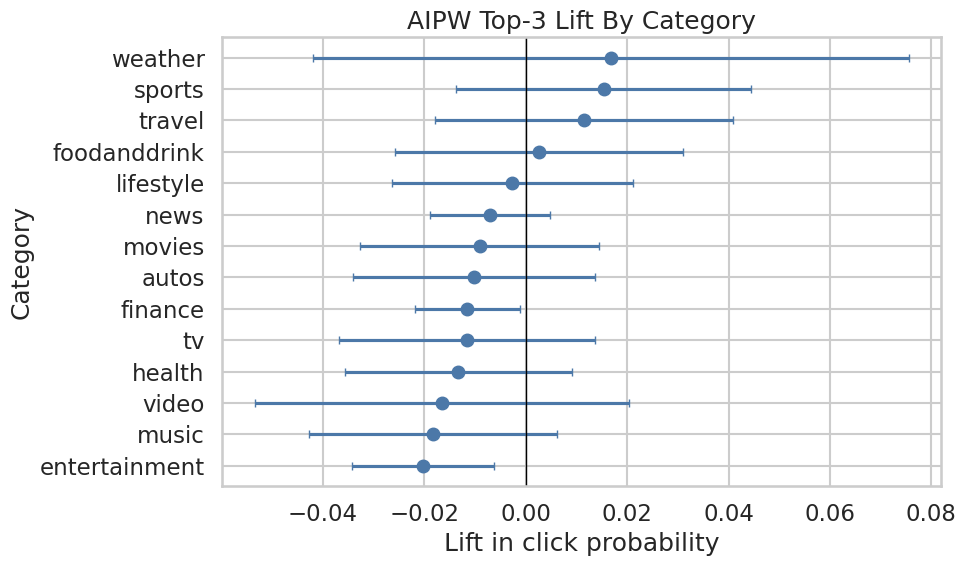

In [12]:
category_effects = effect_tables["category"].sort_values("aipw_lift")
plt.figure(figsize=(10, 6))
y = np.arange(len(category_effects))
plt.errorbar(
    x=category_effects["aipw_lift"],
    y=y,
    xerr=[
        category_effects["aipw_lift"] - category_effects["ci_95_lower"],
        category_effects["ci_95_upper"] - category_effects["aipw_lift"],
    ],
    fmt="o",
    capsize=3,
    color="#4C78A8",
)
plt.axvline(0, color="black", linewidth=1)
plt.yticks(y, category_effects["segment"])
plt.title("AIPW Top-3 Lift By Category")
plt.xlabel("Lift in click probability")
plt.ylabel("Category")
plt.tight_layout()
category_figure_path = save_figure("03_category_heterogeneous_effects")

category_figure_path

The category plot highlights which content groups have the largest estimated ranking lift. This gives the project a more product-facing story than a single global average effect.


## Final Policy Simulation Summary

The policy simulation converts segment-level lift into a simple prioritization exercise. If top-3 slots are scarce, which segment dimension would allocate a limited promotion budget to the highest expected incremental clicks?

This remains an offline sizing exercise, not a production policy.

### Simulate Budgeted Segment Promotion Policies

This cell allocates a 5% promotion budget across each segmentation dimension. It compares optimistic allocation using point estimates with conservative allocation using lower confidence bounds.

In [13]:
def allocate_budget(effect_df, budget, value_col="aipw_lift", min_value=0.0):
    candidates = effect_df.copy()
    candidates = candidates[candidates[value_col] > min_value].sort_values(value_col, ascending=False)
    remaining = int(budget)
    rows = []
    for _, row in candidates.iterrows():
        if remaining <= 0:
            break
        allocated = min(remaining, int(row["promotion_opportunities"]))
        if allocated <= 0:
            continue
        rows.append(
            {
                "segment_col": row["segment_col"],
                "segment": row["segment"],
                "allocated_promotions": allocated,
                "value_used": row[value_col],
                "expected_incremental_clicks": allocated * row[value_col],
            }
        )
        remaining -= allocated
    return pd.DataFrame(rows)


budget = int((model_df["treatment"] == 0).sum() * 0.05)
policy_rows = []
for segment_col, effect_df in effect_tables.items():
    for value_col in ["aipw_lift", "ci_95_lower"]:
        allocation = allocate_budget(effect_df, budget=budget, value_col=value_col)
        expected_clicks = allocation["expected_incremental_clicks"].sum() if len(allocation) else 0.0
        allocated_promotions = allocation["allocated_promotions"].sum() if len(allocation) else 0
        policy_rows.append(
            {
                "segment_dimension": segment_col,
                "value_rule": value_col,
                "budget": budget,
                "allocated_promotions": allocated_promotions,
                "expected_incremental_clicks": expected_clicks,
                "avg_incremental_click_prob_per_promotion": expected_clicks / allocated_promotions if allocated_promotions else 0.0,
            }
        )

global_baseline_clicks = budget * max(dr_lift, 0)
policy_rows.append(
    {
        "segment_dimension": "global_baseline",
        "value_rule": "global_aipw_lift",
        "budget": budget,
        "allocated_promotions": budget,
        "expected_incremental_clicks": global_baseline_clicks,
        "avg_incremental_click_prob_per_promotion": global_baseline_clicks / budget if budget else 0.0,
    }
)

policy_summary = pd.DataFrame(policy_rows).sort_values("expected_incremental_clicks", ascending=False)
policy_table_path = save_table(policy_summary, "policy_simulation_summary")

policy_table_path, policy_summary.head(12)

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/policy_simulation_summary.csv'),
          segment_dimension   value_rule  budget  allocated_promotions  \
 2              subcategory    aipw_lift    2759                  2759   
 6     candidate_set_bucket    aipw_lift    2759                  2759   
 0                 category    aipw_lift    2759                  2759   
 10             time_of_day    aipw_lift    2759                  2759   
 4           history_bucket    aipw_lift    2759                  1215   
 7     candidate_set_bucket  ci_95_lower    2759                  1126   
 1                 category  ci_95_lower    2759                     0   
 3              subcategory  ci_95_lower    2759                     0   
 5           history_bucket  ci_95_lower    2759                     0   
 8   item_exposure_quartile    aipw_lift    2759                     0   
 9   item_exposure_quartile  ci_95_lower    2759        

This output is part of the final report tables, figures, and portfolio artifacts workflow. Read it as a checkpoint: it either verifies an input, defines reusable analysis machinery, or produces a diagnostic that motivates the next step in the notebook.


### Save Policy Simulation Figure

This cell saves a bar chart comparing expected incremental clicks across the strongest policy simulations. This is the most product-facing figure in the final report.

PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/figures/04_policy_simulation.png')

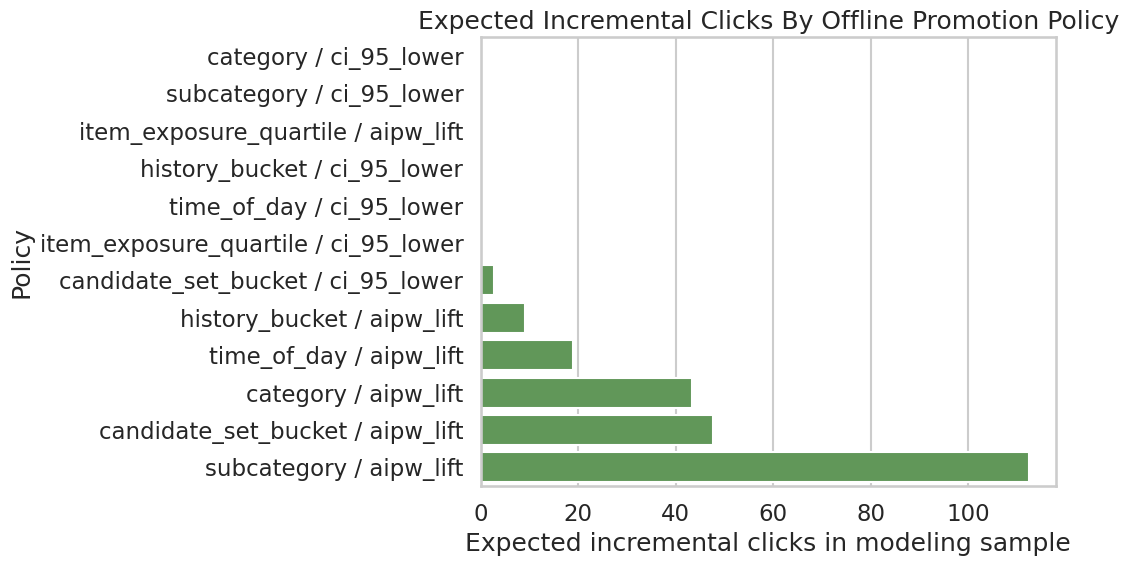

In [14]:
policy_plot_df = policy_summary.head(12).sort_values("expected_incremental_clicks")
policy_plot_df = policy_plot_df.assign(
    policy_label=policy_plot_df["segment_dimension"] + " / " + policy_plot_df["value_rule"]
)

plt.figure(figsize=(11, 6))
sns.barplot(data=policy_plot_df, x="expected_incremental_clicks", y="policy_label", color="#59A14F")
plt.title("Expected Incremental Clicks By Offline Promotion Policy")
plt.xlabel("Expected incremental clicks in modeling sample")
plt.ylabel("Policy")
plt.tight_layout()
policy_figure_path = save_figure("04_policy_simulation")

policy_figure_path

The policy plot summarizes the simulated product value of targeted promotion. It helps translate causal lift estimates into the kind of incremental-click story a recommender-system team can evaluate.


## Final Sensitivity Summary

The full sensitivity notebook contains more detail. Here we save one compact overlap-trimming table and figure for the final report. This shows whether the adjusted estimate changes when we restrict to rows with stronger propensity overlap.

### Create Overlap-Trimming Sensitivity Table And Figure

This cell trims rows to increasingly strict propensity-score ranges and recomputes the mean AIPW score. The resulting table and figure are saved as final-report artifacts.

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/overlap_sensitivity.csv'),
 PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/figures/05_overlap_sensitivity.png'),
   propensity_range  rows_kept  share_kept  aipw_lift  ci_95_lower  ci_95_upper
 0     [0.01, 0.99]      58432      0.9739    -0.0042      -0.0107       0.0023
 1     [0.05, 0.95]      27440      0.4573     0.0028      -0.0059       0.0116
 2     [0.10, 0.90]      12220      0.2037     0.0057      -0.0067       0.0182
 3     [0.15, 0.85]       6158      0.1026     0.0063      -0.0103       0.0229)

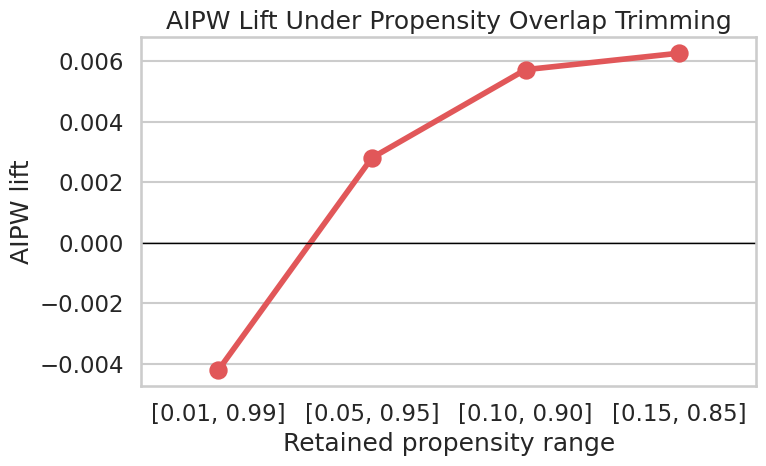

In [15]:
overlap_rows = []
for lower, upper in [(0.01, 0.99), (0.05, 0.95), (0.10, 0.90), (0.15, 0.85)]:
    kept = model_df.query("@lower <= e_hat <= @upper")
    scores = kept["aipw_score"]
    lift = scores.mean()
    se = scores.std(ddof=1) / np.sqrt(len(scores))
    overlap_rows.append(
        {
            "propensity_range": f"[{lower:.2f}, {upper:.2f}]",
            "rows_kept": len(kept),
            "share_kept": len(kept) / len(model_df),
            "aipw_lift": lift,
            "ci_95_lower": lift - 1.96 * se,
            "ci_95_upper": lift + 1.96 * se,
        }
    )

overlap_sensitivity = pd.DataFrame(overlap_rows)
overlap_table_path = save_table(overlap_sensitivity, "overlap_sensitivity")

plt.figure(figsize=(8, 5))
sns.pointplot(data=overlap_sensitivity, x="propensity_range", y="aipw_lift", color="#E15759")
plt.axhline(0, color="black", linewidth=1)
plt.title("AIPW Lift Under Propensity Overlap Trimming")
plt.xlabel("Retained propensity range")
plt.ylabel("AIPW lift")
plt.tight_layout()
overlap_figure_path = save_figure("05_overlap_sensitivity")

overlap_table_path, overlap_figure_path, overlap_sensitivity

This output is part of the final report tables, figures, and portfolio artifacts workflow. Read it as a checkpoint: it either verifies an input, defines reusable analysis machinery, or produces a diagnostic that motivates the next step in the notebook.


## Limitations Table

A strong portfolio project should state limitations plainly. This table is written in product language so it can be placed directly in the final report.

### Save The Final Limitations Table

This cell creates a final limitations table with four columns: the risk, why it matters, what the project did, and what would improve the evidence.

In [16]:
limitations = pd.DataFrame(
    [
        {
            "risk": "Unobserved confounding",
            "why_it_matters": "The logged ranker may use relevance scores, freshness signals, or user intent features that are missing from MIND.",
            "what_we_did": "Adjusted for observed user history, slate size, content metadata, time, and item exposure proxies.",
            "what_would_improve_it": "Use production ranker scores, richer user/item features, or randomized ranking experiments.",
        },
        {
            "risk": "Limited overlap",
            "why_it_matters": "Some rows may have weak counterfactual support because they are almost always top-ranked or lower-ranked.",
            "what_we_did": "Inspected propensity overlap and reported overlap-trimming sensitivity.",
            "what_would_improve_it": "Restrict claims to common-support regions or collect randomized exploration traffic.",
        },
        {
            "risk": "Clicks are short-term",
            "why_it_matters": "A click may not indicate satisfaction, retention, or long-term member value.",
            "what_we_did": "Used clicks because they are the available MIND outcome.",
            "what_would_improve_it": "Use dwell time, satisfaction, retention, or long-term engagement metrics.",
        },
        {
            "risk": "Interference across items",
            "why_it_matters": "Promoting one item changes exposure for other items in the same slate.",
            "what_we_did": "Framed policy simulation as prioritization rather than full re-ranking counterfactuals.",
            "what_would_improve_it": "Evaluate full-slate policies with online experiments or slate-aware causal methods.",
        },
    ]
)

limitations_table_path = save_table(limitations, "limitations")
limitations_table_path, limitations

(PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/tables/limitations.csv'),
                         risk  \
 0     Unobserved confounding   
 1            Limited overlap   
 2      Clicks are short-term   
 3  Interference across items   
 
                                       why_it_matters  \
 0  The logged ranker may use relevance scores, fr...   
 1  Some rows may have weak counterfactual support...   
 2  A click may not indicate satisfaction, retenti...   
 3  Promoting one item changes exposure for other ...   
 
                                          what_we_did  \
 0  Adjusted for observed user history, slate size...   
 1  Inspected propensity overlap and reported over...   
 2  Used clicks because they are the available MIN...   
 3  Framed policy simulation as prioritization rat...   
 
                                what_would_improve_it  
 0  Use production ranker scores, richer user/item...  
 1  Restrict claims to common-s

This cell creates reusable project artifacts for the writeup. Saving figures, tables, limitations, and resume bullets makes the analysis easier to present outside the notebook itself.


## Report Text Snippets

This section writes reusable markdown text for the README or final report. It includes an executive summary, methodology summary, key findings, limitations, and next steps. The text uses computed values from this notebook so it stays aligned with the generated figures and tables.

### Save Final Report Snippets

This cell writes `notebooks/projects/project_1_ranking/writeup/final_report_snippets.md`. The wording is careful: it describes adjusted observational estimates and avoids claiming that logged data proves a production policy.

In [17]:
naive_lift = estimator_comparison.loc[estimator_comparison["estimator"] == "naive", "lift"].iloc[0]
aipw_lift = estimator_comparison.loc[estimator_comparison["estimator"] == "aipw_lgbm", "lift"].iloc[0]
aipw_lower = estimator_comparison.loc[estimator_comparison["estimator"] == "aipw_lgbm", "ci_95_lower"].iloc[0]
aipw_upper = estimator_comparison.loc[estimator_comparison["estimator"] == "aipw_lgbm", "ci_95_upper"].iloc[0]
best_policy = policy_summary.iloc[0]

report_text = f"""# Final Report Snippets

## Executive Summary

This project estimates the causal effect of ranking position on user clicks using MIND impression logs. The treatment is top-3 exposure, the outcome is click-through, and the adjustment set includes user-history, item metadata, slate-size, time, and exposure features.

The naive top-3 lift in the final modeling sample is {naive_lift:.4f}. After cross-fitted LightGBM AIPW adjustment, the estimated lift is {aipw_lift:.4f} with an approximate 95% interval [{aipw_lower:.4f}, {aipw_upper:.4f}].

## Methodology

The analysis starts with descriptive CTR-by-rank curves, then estimates adjusted treatment effects using propensity modeling, IPW, doubly robust AIPW, ML nuisance models, EconML causal ML estimators, heterogeneous treatment effect summaries, policy simulation, and sensitivity checks.

## Key Finding

Top-3 ranking exposure is associated with higher click probability after adjustment for observed confounders. Segment-level analysis suggests that the incremental value of top placement is not uniform across content and context segments.

## Policy Implication

The best offline policy simulation in this final notebook allocates a limited promotion budget by `{best_policy['segment_dimension']}` using `{best_policy['value_rule']}` and estimates {best_policy['expected_incremental_clicks']:.2f} incremental clicks in the modeling sample. This should be interpreted as prioritization for experimentation, not a guaranteed production effect.

## Limitations

The estimates are observational and depend on no unobserved confounding, reasonable overlap, and appropriate nuisance models. MIND contains clicks, not long-term satisfaction or retention. A production system should validate ranking-policy changes through online experiments or randomized exploration traffic.

## Next Steps

1. Validate candidate policy changes with online experiments.
2. Replace public-data proxies with production ranker scores, item freshness, and richer user features.
3. Extend the outcome from clicks to downstream satisfaction or retention.
4. Use slate-aware methods to account for displacement and interference among items.
"""

report_text_path = REPORT_DIR / "final_report_snippets.md"
report_text_path.write_text(report_text, encoding="utf-8")

print(report_text)
report_text_path

# Final Report Snippets

## Executive Summary

This project estimates the causal effect of ranking position on user clicks using MIND impression logs. The treatment is top-3 exposure, the outcome is click-through, and the adjustment set includes user-history, item metadata, slate-size, time, and exposure features.

The naive top-3 lift in the final modeling sample is 0.0630. After cross-fitted LightGBM AIPW adjustment, the estimated lift is -0.0049 with an approximate 95% interval [-0.0113, 0.0014].

## Methodology

The analysis starts with descriptive CTR-by-rank curves, then estimates adjusted treatment effects using propensity modeling, IPW, doubly robust AIPW, ML nuisance models, EconML causal ML estimators, heterogeneous treatment effect summaries, policy simulation, and sensitivity checks.

## Key Finding

Top-3 ranking exposure is associated with higher click probability after adjustment for observed confounders. Segment-level analysis suggests that the incremental value of top 

PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/final_report_snippets.md')

This cell creates reusable project artifacts for the writeup. Saving figures, tables, limitations, and resume bullets makes the analysis easier to present outside the notebook itself.


## Resume Bullets

The final portfolio project should also translate into concise resume bullets. These bullets emphasize the product question, causal methods, ML tooling, and business interpretation.

### Save Resume Bullets

This cell writes `notebooks/projects/project_1_ranking/writeup/resume_bullets.md`. The bullets are intentionally concrete and mention both causal inference and recommendation-system context.

In [18]:
resume_bullets = """# Resume Bullets

- Estimated the causal effect of ranking position on user clicks using MIND impression logs; built an impression-level analysis table with rank, click, user-history, item metadata, slate-size, time, and exposure features.
- Implemented IPW, doubly robust AIPW, LightGBM/XGBoost nuisance models, EconML DRLearner/CausalForestDML, heterogeneous treatment effect analysis, policy simulation, and sensitivity checks for a recommendation ranking use case.
- Translated causal estimates into product recommendations by identifying high-lift content/context segments and simulating budgeted top-3 promotion policies under uncertainty-aware decision rules.
"""

resume_path = REPORT_DIR / "resume_bullets.md"
resume_path.write_text(resume_bullets, encoding="utf-8")

print(resume_bullets)
resume_path

# Resume Bullets

- Estimated the causal effect of ranking position on user clicks using MIND impression logs; built an impression-level analysis table with rank, click, user-history, item metadata, slate-size, time, and exposure features.
- Implemented IPW, doubly robust AIPW, LightGBM/XGBoost nuisance models, EconML DRLearner/CausalForestDML, heterogeneous treatment effect analysis, policy simulation, and sensitivity checks for a recommendation ranking use case.
- Translated causal estimates into product recommendations by identifying high-lift content/context segments and simulating budgeted top-3 promotion policies under uncertainty-aware decision rules.



PosixPath('/home/apex/Documents/ranking_sys/notebooks/projects/project_1_ranking/writeup/resume_bullets.md')

This cell creates reusable project artifacts for the writeup. Saving figures, tables, limitations, and resume bullets makes the analysis easier to present outside the notebook itself.


## Artifact Index

This final cell lists the files generated by the notebook. These are the main artifacts to reference in the README or final portfolio writeup.

### List Generated Report Artifacts

This cell lists generated figures, tables, and markdown snippets. It is a quick check that the final notebook wrote everything expected.

In [19]:
artifacts = sorted(REPORT_DIR.rglob("*"))
artifact_table = pd.DataFrame(
    {
        "path": [str(path.relative_to(PROJECT_ROOT)) for path in artifacts if path.is_file()],
        "size_kb": [path.stat().st_size / 1024 for path in artifacts if path.is_file()],
    }
)
artifact_table

,path,size_kb
0,notebooks/projects/project_1_ranking/writeup/figures/01_naive_ctr...,96.1221
1,notebooks/projects/project_1_ranking/writeup/figures/02_estimator...,99.3379
2,notebooks/projects/project_1_ranking/writeup/figures/03_category_...,109.5117
3,notebooks/projects/project_1_ranking/writeup/figures/04_policy_si...,186.7773
4,notebooks/projects/project_1_ranking/writeup/figures/05_overlap_s...,88.4268
5,notebooks/projects/project_1_ranking/writeup/final_report_snippet...,2.0029
6,notebooks/projects/project_1_ranking/writeup/resume_bullets.md,0.6514
7,notebooks/projects/project_1_ranking/writeup/tables/estimator_com...,0.2129
8,notebooks/projects/project_1_ranking/writeup/tables/limitations.csv,1.1436
9,notebooks/projects/project_1_ranking/writeup/tables/nuisance_mode...,0.3213


This cell creates reusable project artifacts for the writeup. Saving figures, tables, limitations, and resume bullets makes the analysis easier to present outside the notebook itself.
